In [24]:
import os
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchaudio

from transformers import (
    Wav2Vec2Model,
    Wav2Vec2FeatureExtractor,
    HubertModel,
)

print("Torch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.5.1
Torchaudio: 2.5.1a0
CUDA available: True
GPU: NVIDIA GeForce RTX 4070


In [25]:
RAVDESS_DIR = Path(r"/home/mattdbr/perso/work/ser-recognition/RAVDESS")

# Dossier où sauvegarder le modèle + logs
RUN_DIR = Path(r"/home/mattdbr/perso/work/ser-recognition/output")
RUN_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2) HYPERPARAMETRES
# =========================
SEED = 42
NUM_EPOCHS = 25            # Augmenté pour early stopping (on n'atteindra probablement pas la fin)

BATCH_SIZE = 8            # Audio = plus de mémoire, réduire si OOM
NUM_WORKERS = 0           # Windows: 0
PIN_MEMORY = torch.cuda.is_available()

LR_HEAD = 4e-4            # lr pour la tête (classifier) - réduit de 1e-3 à 4e-4 pour réduire overfitting
LR_BACKBONE = 1e-5        # lr plus petit pour Wav2Vec2 (très sensible)
WEIGHT_DECAY = 5e-4       # Augmenté de 1e-4 à 5e-4 pour plus de régularisation

# Fine-tuning progressif
EPOCHS_HEAD_ONLY = 6      # epochs: on entraîne seulement la tête - augmenté de 3 à 6 pour geler plus longtemps
UNFREEZE_AT_EPOCH = EPOCHS_HEAD_ONLY

# Early stopping
EARLY_STOPPING_PATIENCE = 5  # Arrêter si val_loss ne s'améliore pas pendant 5 epochs

# Audio params
SAMPLE_RATE = 16000       # Wav2Vec2 attend 16kHz
MAX_DURATION = 5.0        # secondes max (padding/truncation)
MAX_LENGTH = int(SAMPLE_RATE * MAX_DURATION)

# Modèle backbone
MODEL_NAME = "facebook/wav2vec2-base"  # ou "facebook/hubert-base-ls960"
HIDDEN_SIZE = 768         # taille des embeddings (base=768, large=1024)

# AMP
USE_AMP = torch.cuda.is_available()

# =========================
# 3) LABELS RAVDESS
# =========================
# RAVDESS: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised
# On mappe vers les mêmes émotions que la vision pour la fusion
RAVDESS_EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",       # pas dans vision, on peut fusionner avec neutral ou garder
    "03": "happy",
    "04": "sad",
    "05": "anger",
    "06": "fear",
    "07": "disgust",
    "08": "surprise",
}

# Émotions finales (alignées avec vision, sans contempt car absent de RAVDESS)
EMOTIONS = ["neutral", "calm", "happy", "sad", "anger", "fear", "disgust", "surprise"]

print("RAVDESS_DIR:", RAVDESS_DIR)
print("RUN_DIR:", RUN_DIR)
print("Emotions:", EMOTIONS)
print("Model:", MODEL_NAME)

RAVDESS_DIR: /home/mattdbr/perso/work/ser-recognition/RAVDESS
RUN_DIR: /home/mattdbr/perso/work/ser-recognition/output
Emotions: ['neutral', 'calm', 'happy', 'sad', 'anger', 'fear', 'disgust', 'surprise']
Model: facebook/wav2vec2-base


In [26]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [27]:
def parse_ravdess_filename(filepath):
    """
    RAVDESS filename format: 03-01-06-01-02-01-12.wav
    - Modality (01=full-AV, 02=video-only, 03=audio-only)
    - Vocal channel (01=speech, 02=song)
    - Emotion (01-08)
    - Emotional intensity (01=normal, 02=strong)
    - Statement (01="Kids are talking by the door", 02="Dogs are sitting by the door")
    - Repetition (01=1st, 02=2nd)
    - Actor (01-24, odd=male, even=female)
    """
    filename = Path(filepath).stem
    parts = filename.split("-")
    
    if len(parts) != 7:
        return None
    
    emotion_code = parts[2]
    intensity = parts[3]
    actor = int(parts[6])
    gender = "male" if actor % 2 == 1 else "female"
    
    emotion = RAVDESS_EMOTION_MAP.get(emotion_code, None)
    
    return {
        "path": str(filepath),
        "emotion_code": emotion_code,
        "emotion": emotion,
        "intensity": intensity,
        "actor": actor,
        "gender": gender,
    }

# Scanner tous les fichiers
records = []
for actor_dir in RAVDESS_DIR.iterdir():
    if actor_dir.is_dir():
        for wav_file in actor_dir.glob("*.wav"):
            info = parse_ravdess_filename(wav_file)
            if info and info["emotion"]:
                records.append(info)

df = pd.DataFrame(records)
print(f"Total fichiers audio: {len(df)}")
print(df["emotion"].value_counts())
print(df["gender"].value_counts())
df.head()

Total fichiers audio: 1440
emotion
sad         192
fear        192
calm        192
anger       192
happy       192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64
gender
female    720
male      720
Name: count, dtype: int64


,path,emotion_code,emotion,intensity,actor,gender
0,/home/mattdbr/perso/work/ser-recognition/RAVDE...,04,sad,02,24,female
1,/home/mattdbr/perso/work/ser-recognition/RAVDE...,06,fear,01,24,female
2,/home/mattdbr/perso/work/ser-recognition/RAVDE...,02,calm,02,24,female
3,/home/mattdbr/perso/work/ser-recognition/RAVDE...,05,anger,01,24,female
4,/home/mattdbr/perso/work/ser-recognition/RAVDE...,03,happy,02,24,female


In [28]:
# Speaker-independent split: 20 acteurs train, 4 acteurs val
all_actors = df["actor"].unique()
np.random.seed(SEED)
np.random.shuffle(all_actors)

n_val_actors = 4
val_actors = set(all_actors[:n_val_actors])
train_actors = set(all_actors[n_val_actors:])

print(f"Train actors ({len(train_actors)}): {sorted(train_actors)}")
print(f"Val actors ({len(val_actors)}): {sorted(val_actors)}")

df["split"] = df["actor"].apply(lambda x: "val" if x in val_actors else "train")
print(df["split"].value_counts())

Train actors (20): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Val actors (4): [np.int64(4), np.int64(8), np.int64(17), np.int64(24)]
split
train    1200
val       240
Name: count, dtype: int64


In [29]:
emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}
idx_to_emotion = {i: e for e, i in emotion_to_idx.items()}

df["y"] = df["emotion"].map(emotion_to_idx).astype(int)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("\nTrain distribution:")
print(train_df["emotion"].value_counts())
print("\nVal distribution:")
print(val_df["emotion"].value_counts())

Train: 1200 | Val: 240

Train distribution:
emotion
anger       160
happy       160
fear        160
calm        160
surprise    160
disgust     160
sad         160
neutral      80
Name: count, dtype: int64

Val distribution:
emotion
sad         32
fear        32
calm        32
anger       32
happy       32
disgust     32
surprise    32
neutral     16
Name: count, dtype: int64


## 6.5. Data Augmentation Audio

In [31]:
import librosa

def noise(data):
    """Ajoute du bruit gaussien au signal audio."""
    noise_amp = 0.04 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def time_shift(data):
    """Décale le signal temporellement."""
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def stretch(data, rate=0.8):
    """Étire ou compresse le signal temporellement."""
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch_change(data, sampling_rate, n_steps=0.8):
    """Change la hauteur tonale du signal."""
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

def apply_augmentation(waveform_np, sample_rate, prob=0.6):
    """
    Applique une augmentation aléatoire avec probabilité prob.
    
    Args:
        waveform_np: Signal audio en numpy array
        sample_rate: Taux d'échantillonnage
        prob: Probabilité d'appliquer une augmentation (0.6 = 60%)
    
    Returns:
        Signal audio augmenté ou original
    """
    if np.random.random() > prob:
        return waveform_np
    
    aug_type = np.random.choice(['noise', 'time_shift', 'stretch', 'pitch', 'none'])
    
    try:
        if aug_type == 'noise':
            return noise(waveform_np)
        elif aug_type == 'time_shift':
            return time_shift(waveform_np)
        elif aug_type == 'stretch':
            rate = np.random.uniform(0.85, 1.15)
            stretched = stretch(waveform_np, rate=rate)
            # S'assurer que la longueur est préservée (padding/truncation si nécessaire)
            if len(stretched) > len(waveform_np):
                return stretched[:len(waveform_np)]
            elif len(stretched) < len(waveform_np):
                padding = len(waveform_np) - len(stretched)
                return np.pad(stretched, (0, padding), mode='constant')
            return stretched
        elif aug_type == 'pitch':
            n_steps = np.random.uniform(-2, 2)
            pitch_shifted = pitch_change(waveform_np, sample_rate, n_steps=n_steps)
            # S'assurer que la longueur est préservée
            if len(pitch_shifted) > len(waveform_np):
                return pitch_shifted[:len(waveform_np)]
            elif len(pitch_shifted) < len(waveform_np):
                padding = len(waveform_np) - len(pitch_shifted)
                return np.pad(pitch_shifted, (0, padding), mode='constant')
            return pitch_shifted
        else:
            return waveform_np
    except Exception as e:
        # En cas d'erreur, retourner le signal original
        print(f"Erreur dans augmentation {aug_type}: {e}")
        return waveform_np

print("✅ Fonctions d'augmentation audio chargées")

✅ Fonctions d'augmentation audio chargées


In [32]:
class RAVDESSDataset(Dataset):
    def __init__(self, df, feature_extractor, max_length=MAX_LENGTH, sample_rate=SAMPLE_RATE, augment=False):
        self.df = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.max_length = max_length
        self.sample_rate = sample_rate
        self.augment = augment  # Activer l'augmentation pour le train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = row["path"]
        y = int(row["y"])

        # Charger audio
        waveform, sr = torchaudio.load(audio_path)
        
        # Resample si nécessaire
        if sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
            waveform = resampler(waveform)
        
        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        
        waveform = waveform.squeeze(0)  # (T,)
        
        # Convertir en numpy pour l'augmentation
        waveform_np = waveform.numpy()
        
        # Appliquer l'augmentation si activée (uniquement pour le train)
        if self.augment:
            waveform_np = apply_augmentation(waveform_np, self.sample_rate, prob=0.6)
            # Reconvertir en tensor pour le padding/truncation
            waveform = torch.from_numpy(waveform_np).float()
        
        # Padding / Truncation
        if len(waveform) > self.max_length:
            waveform = waveform[:self.max_length]
        elif len(waveform) < self.max_length:
            padding = self.max_length - len(waveform)
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        
        return waveform.numpy(), y, audio_path


def collate_fn(batch, feature_extractor):
    """Collate avec le feature extractor de HuggingFace."""
    waveforms = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    paths = [item[2] for item in batch]
    
    # Feature extractor normalise et crée attention_mask
    inputs = feature_extractor(
        waveforms,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True,
    )
    
    return inputs, labels, paths

In [33]:
# Charger le feature extractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)

# Datasets - activation de l'augmentation uniquement pour le train
train_ds = RAVDESSDataset(train_df, feature_extractor, augment=True)
val_ds = RAVDESSDataset(val_df, feature_extractor, augment=False)

# Créer une fonction collate avec feature_extractor fixé
from functools import partial
collate_fn_bound = partial(collate_fn, feature_extractor=feature_extractor)

# DataLoaders
train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn_bound,
)

val_dl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_fn_bound,
)

print(f"Train batches: {len(train_dl)} | Val batches: {len(val_dl)}")

Train batches: 150 | Val batches: 30


In [34]:
class SERModel(nn.Module):
    """
    Speech Emotion Recognition avec Wav2Vec2/HuBERT.
    Produit des embeddings de taille HIDDEN_SIZE pour la fusion multimodale.
    """
    def __init__(
        self,
        model_name=MODEL_NAME,
        num_classes=len(EMOTIONS),
        hidden_size=HIDDEN_SIZE,
        pooling="mean",  # "mean", "attention", "last"
    ):
        super().__init__()
        
        # Charger le backbone (utiliser safetensors pour éviter l'erreur de sécurité)
        if "hubert" in model_name.lower():
            self.encoder = HubertModel.from_pretrained(model_name, use_safetensors=True)
        else:
            self.encoder = Wav2Vec2Model.from_pretrained(model_name, use_safetensors=True)
        
        self.hidden_size = hidden_size
        self.pooling = pooling
        
        # Attention pooling (optionnel)
        if pooling == "attention":
            self.attention = nn.Sequential(
                nn.Linear(hidden_size, 128),
                nn.Tanh(),
                nn.Linear(128, 1),
            )
        
        # Projection layer (pour embeddings finaux) - dropout augmenté pour réduire overfitting
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.4),  # Augmenté de 0.1 à 0.4 pour plus de régularisation
        )
        
        # Dropout supplémentaire avant le classifier
        self.dropout_before_classifier = nn.Dropout(0.3)
        
        # Classification head
        self.classifier = nn.Linear(hidden_size, num_classes)
    
    def pool_hidden_states(self, hidden_states, attention_mask=None):
        """Pooling des séquences temporelles en un vecteur fixe."""
        if self.pooling == "mean":
            if attention_mask is not None:
                # Masked mean pooling
                mask = attention_mask.unsqueeze(-1).float()
                pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
            else:
                pooled = hidden_states.mean(dim=1)
        
        elif self.pooling == "attention":
            # Attention-weighted pooling
            attn_weights = self.attention(hidden_states)  # (B, T, 1)
            if attention_mask is not None:
                attn_weights = attn_weights.masked_fill(
                    ~attention_mask.unsqueeze(-1).bool(), float("-inf")
                )
            attn_weights = torch.softmax(attn_weights, dim=1)
            pooled = (hidden_states * attn_weights).sum(dim=1)
        
        elif self.pooling == "last":
            # Dernier token (ou dernier valide si masque)
            if attention_mask is not None:
                lengths = attention_mask.sum(dim=1) - 1
                pooled = hidden_states[torch.arange(hidden_states.size(0)), lengths]
            else:
                pooled = hidden_states[:, -1, :]
        
        return pooled
    
    def forward(self, input_values, attention_mask=None, return_embeddings=False):
        """
        Args:
            input_values: (B, T) waveform
            attention_mask: (B, T) mask
            return_embeddings: si True, retourne aussi les embeddings
        
        Returns:
            logits: (B, num_classes)
            embeddings: (B, hidden_size) si return_embeddings=True
        """
        # Encoder
        outputs = self.encoder(
            input_values,
            attention_mask=attention_mask,
            output_hidden_states=False,
        )
        hidden_states = outputs.last_hidden_state  # (B, T', hidden_size)
        
        # Pooling (utiliser attention_mask si fourni)
        pooled = self.pool_hidden_states(hidden_states, attention_mask=attention_mask)
        
        # Projection (embeddings pour fusion)
        embeddings = self.projector(pooled)  # (B, hidden_size)
        
        # Dropout supplémentaire avant classification
        embeddings = self.dropout_before_classifier(embeddings)
        
        # Classification
        logits = self.classifier(embeddings)
        
        if return_embeddings:
            return logits, embeddings
        return logits
    
    def extract_embeddings(self, input_values, attention_mask=None):
        """Extraction des embeddings uniquement (pour inférence/fusion)."""
        self.eval()
        with torch.no_grad():
            _, embeddings = self.forward(
                input_values,
                attention_mask=attention_mask,
                return_embeddings=True,
            )
        return embeddings


# Instancier le modèle
model = SERModel(model_name=MODEL_NAME, pooling="mean")
model = model.to(DEVICE)

# Vérifier la taille des embeddings
print(f"Embedding size: {model.hidden_size}")
print(f"Classifier: {model.classifier}")

/home/mattdbr/miniconda3/envs/speech/lib/python3.10/site-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Embedding size: 768
Classifier: Linear(in_features=768, out_features=8, bias=True)


## 9. Geler / dégeler (fine-tuning progressif)

In [35]:
def freeze_backbone(m):
    """Gèle tout sauf la tête (projector + classifier)."""
    for name, param in m.named_parameters():
        if name.startswith("encoder."):
            param.requires_grad = False
        else:
            param.requires_grad = True

def unfreeze_all(m):
    """Dégèle tous les paramètres."""
    for param in m.parameters():
        param.requires_grad = True

# Au début: head only (projector + classifier)
freeze_backbone(model)

# Vérification
trainable = [n for n, p in model.named_parameters() if p.requires_grad]
frozen = [n for n, p in model.named_parameters() if not p.requires_grad]
print(f"Paramètres entraînables (début): {len(trainable)}")
print(f"Paramètres gelés: {len(frozen)}")
print(f"Exemples entraînables: {trainable[:5]}")

Paramètres entraînables (début): 4
Paramètres gelés: 211
Exemples entraînables: ['projector.0.weight', 'projector.0.bias', 'classifier.weight', 'classifier.bias']


## 10. Optimiseur (LR différent backbone vs head)

In [36]:
def build_optimizer(m):
    """Construit un optimiseur avec LR différents pour backbone et head."""
    head_params = []
    backbone_params = []

    for name, param in m.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith("encoder."):
            backbone_params.append(param)
        else:
            head_params.append(param)

    # Si backbone gelé => backbone_params vide
    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": LR_BACKBONE})
    if head_params:
        param_groups.append({"params": head_params, "lr": LR_HEAD})

    opt = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    return opt

optimizer = build_optimizer(model)
criterion = nn.CrossEntropyLoss()

# Scheduler simple
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# AMP scaler
if USE_AMP:
    scaler = torch.cuda.amp.GradScaler()
else:
    scaler = None

print("Optimizer param groups:", len(optimizer.param_groups))
for i, g in enumerate(optimizer.param_groups):
    print(i, "lr=", g["lr"], "n_params=", sum(p.numel() for p in g["params"]))

Optimizer param groups: 1
0 lr= 0.0004 n_params= 596744


/tmp/ipykernel_19912/2822886167.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 11. Métriques (accuracy, confusion matrix)

In [37]:
@torch.no_grad()
def evaluate(model, dataloader):
    """Évaluation du modèle sur un dataloader."""
    model.eval()
    total = 0
    correct = 0
    loss_sum = 0.0

    all_preds = []
    all_targets = []

    for inputs, y, _ in dataloader:
        input_values = inputs["input_values"].to(DEVICE, non_blocking=True)
        attention_mask = inputs.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(input_values, attention_mask=attention_mask)
        loss = criterion(logits, y)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        loss_sum += loss.item() * y.size(0)

        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds) if all_preds else np.array([])
    all_targets = np.concatenate(all_targets) if all_targets else np.array([])

    acc = correct / max(1, total)
    avg_loss = loss_sum / max(1, total)
    return avg_loss, acc, all_targets, all_preds

def confusion_matrix_np(y_true, y_pred, n_classes):
    """Calcule la matrice de confusion."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

## 12. Boucle d'entraînement (head-only puis fine-tuning)

In [38]:
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, optimizer, epoch):
    """Entraîne le modèle pendant une époque."""
    model.train()
    total = 0
    correct = 0
    loss_sum = 0.0

    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---", flush=True)

    pbar = tqdm(
        dataloader,
        total=len(dataloader),
        desc=f"Training",
        leave=True,
        dynamic_ncols=True,
        mininterval=0.1
    )

    for inputs, y, _ in pbar:
        input_values = inputs["input_values"].to(DEVICE, non_blocking=True)
        attention_mask = inputs.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast("cuda"):
                logits = model(input_values, attention_mask=attention_mask)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(input_values, attention_mask=attention_mask)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        loss_sum += loss.item() * y.size(0)

        acc_running = correct / max(1, total)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc_running:.3f}"
        })

    acc = correct / max(1, total)
    avg_loss = loss_sum / max(1, total)
    return avg_loss, acc


best_val_acc = 0.0
best_val_loss = float('inf')
best_path = RUN_DIR / "best_model.pt"
history = []

# Early stopping
patience_counter = 0
early_stopped = False

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    if epoch == UNFREEZE_AT_EPOCH:
        print(f"\n🔓 Unfreeze backbone at epoch {epoch}", flush=True)
        unfreeze_all(model)
        optimizer = build_optimizer(model)
        # Utiliser ReduceLROnPlateau pour le scheduler (basé sur val_loss)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
    elif epoch == 0:
        # Pour les premières epochs (head only), utiliser CosineAnnealingLR
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=UNFREEZE_AT_EPOCH
        )

    train_loss, train_acc = train_one_epoch(model, train_dl, optimizer, epoch)
    val_loss, val_acc, y_true, y_pred = evaluate(model, val_dl)

    # Scheduler step (basé sur val_loss pour ReduceLROnPlateau après unfreeze)
    if epoch >= UNFREEZE_AT_EPOCH:
        scheduler.step(val_loss)
    else:
        scheduler.step()

    # Sauvegarder le meilleur modèle basé sur val_loss (meilleur indicateur que val_acc)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "model_state": model.state_dict(),
            "emotion_to_idx": emotion_to_idx,
            "idx_to_emotion": idx_to_emotion,
            "sample_rate": SAMPLE_RATE,
            "max_length": MAX_LENGTH,
            "model_name": MODEL_NAME,
            "hidden_size": HIDDEN_SIZE,
            "pooling": "mean",
            "epoch": epoch,
            "val_acc": val_acc,
            "val_loss": val_loss
        }, best_path)
    else:
        patience_counter += 1

    lr_list = [g["lr"] for g in optimizer.param_groups]
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lrs": lr_list,
    })

    print(
        f"✅ Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={lr_list[0]:.2e} | patience={patience_counter}/{EARLY_STOPPING_PATIENCE}",
        flush=True
    )

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️  Early stopping déclenché après {epoch+1} epochs (patience={EARLY_STOPPING_PATIENCE})")
        print(f"   Meilleur val_loss: {best_val_loss:.4f} à l'epoch {epoch+1-patience_counter}")
        early_stopped = True
        break

elapsed = time.time() - start_time
if not early_stopped:
    print(f"\n✅ Training terminé en {elapsed/60:.1f} minutes. Best val_acc={best_val_acc:.4f}, val_loss={best_val_loss:.4f}")
else:
    print(f"\n✅ Training arrêté en {elapsed/60:.1f} minutes. Best val_acc={best_val_acc:.4f}, val_loss={best_val_loss:.4f}")
print("Best model:", best_path)


--- Epoch 1/25 ---


Training: 100%|██████████| 150/150 [00:35<00:00,  4.23it/s, loss=1.9995, acc=0.172]


✅ Epoch 1/25 | train_loss=2.0267 train_acc=0.1725 | val_loss=1.9335 val_acc=0.3083 | lr=3.73e-04 | patience=0/5

--- Epoch 2/25 ---


Training: 100%|██████████| 150/150 [00:26<00:00,  5.63it/s, loss=2.1636, acc=0.253]


✅ Epoch 2/25 | train_loss=1.9156 train_acc=0.2525 | val_loss=1.8341 val_acc=0.2708 | lr=3.00e-04 | patience=0/5

--- Epoch 3/25 ---


...

✅ Epoch 14/25 | train_loss=0.3051 train_acc=0.8875 | val_loss=0.9667 val_acc=0.7417 | lr=1.00e-05 | patience=3/5

--- Epoch 15/25 ---


Training: 100%|██████████| 150/150 [00:32<00:00,  4.56it/s, loss=0.5482, acc=0.891]


✅ Epoch 15/25 | train_loss=0.3103 train_acc=0.8908 | val_loss=0.8960 val_acc=0.7375 | lr=5.00e-06 | patience=4/5

--- Epoch 16/25 ---


Training: 100%|██████████| 150/150 [00:32<00:00,  4.56it/s, loss=0.6736, acc=0.947]


✅ Epoch 16/25 | train_loss=0.1487 train_acc=0.9467 | val_loss=0.9735 val_acc=0.7208 | lr=5.00e-06 | patience=5/5

⏹️  Early stopping déclenché après 16 epochs (patience=5)
   Meilleur val_loss: 0.7567 à l'epoch 11

✅ Training arrêté en 9.2 minutes. Best val_acc=0.7417, val_loss=0.7567
Best model: /home/mattdbr/perso/work/ser-recognition/output/best_model.pt


## 13. Sauvegarder l'historique + courbes

History saved: /home/mattdbr/perso/work/ser-recognition/output/training_history.json


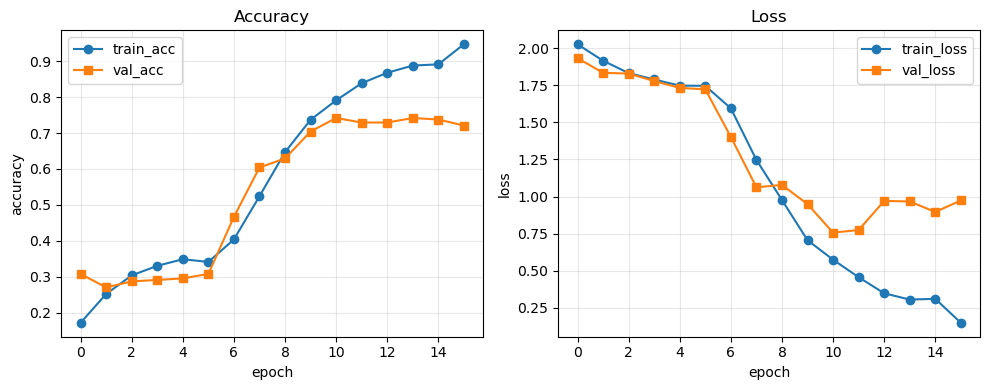

In [43]:
import matplotlib.pyplot as plt

hist_path = RUN_DIR / "training_history.json"
with open(hist_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print("History saved:", hist_path)

epochs = [h["epoch"] for h in history]
train_accs = [h["train_acc"] for h in history]
val_accs = [h["val_acc"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_losses = [h["val_loss"] for h in history]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label="train_acc", marker="o")
plt.plot(epochs, val_accs, label="val_acc", marker="s")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Accuracy")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label="train_loss", marker="o")
plt.plot(epochs, val_losses, label="val_loss", marker="s")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / "training_curves.png", dpi=150)
plt.show()

## 14. Confusion matrix sur validation

/tmp/ipykernel_19912/2387306451.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=DEVICE)


Best model val_acc: 0.7416666666666667


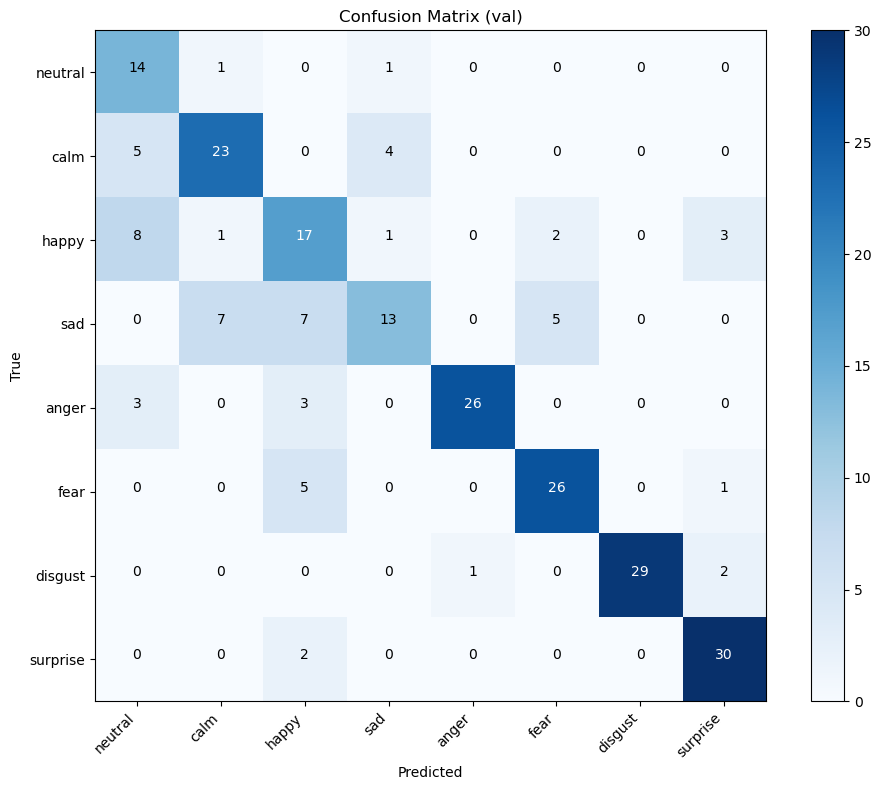

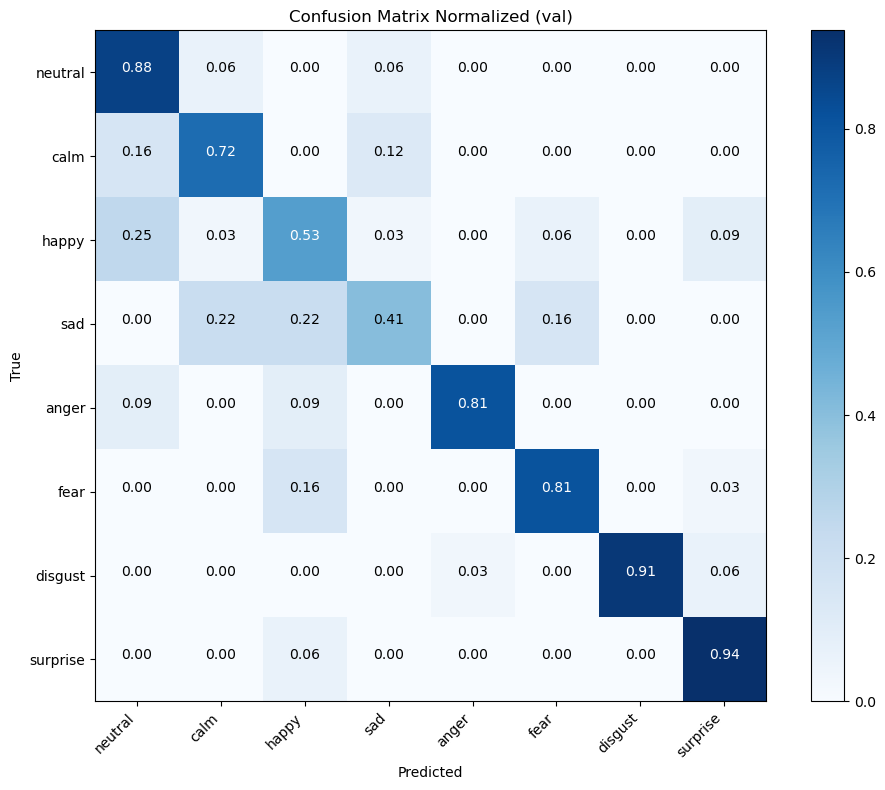

In [44]:
# Charger le meilleur modèle puis évaluer
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

val_loss, val_acc, y_true, y_pred = evaluate(model, val_dl)
print("Best model val_acc:", val_acc)

cm = confusion_matrix_np(y_true, y_pred, n_classes=len(EMOTIONS))

# Affichage simple
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(EMOTIONS)), EMOTIONS, rotation=45, ha="right")
plt.yticks(np.arange(len(EMOTIONS)), EMOTIONS)

# Ajouter les valeurs dans les cases
thresh = cm.max() / 2.0
for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        plt.text(j, i, format(cm[i, j], "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

plt.colorbar()
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix.png", dpi=150)
plt.show()

# Option: normaliser
cm_norm = cm / np.maximum(1, cm.sum(axis=1, keepdims=True))
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix Normalized (val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(EMOTIONS)), EMOTIONS, rotation=45, ha="right")
plt.yticks(np.arange(len(EMOTIONS)), EMOTIONS)

# Ajouter les valeurs normalisées
thresh = cm_norm.max() / 2.0
for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        plt.text(j, i, format(cm_norm[i, j], ".2f"),
                horizontalalignment="center",
                color="white" if cm_norm[i, j] > thresh else "black")

plt.colorbar()
plt.tight_layout()
plt.savefig(RUN_DIR / "confusion_matrix_normalized.png", dpi=150)
plt.show()

## 15. Fonction d'inférence sur un fichier audio

In [45]:
@torch.no_grad()
def predict_audio(model, audio_path, feature_extractor, return_embeddings=False):
    """Prédit l'émotion d'un fichier audio."""
    model.eval()
    
    # Charger et préprocesser l'audio
    waveform, sr = torchaudio.load(audio_path)
    
    # Resample si nécessaire
    if sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
        waveform = resampler(waveform)
    
    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    
    waveform = waveform.squeeze(0).numpy()
    
    # Padding / Truncation
    if len(waveform) > MAX_LENGTH:
        waveform = waveform[:MAX_LENGTH]
    elif len(waveform) < MAX_LENGTH:
        padding = MAX_LENGTH - len(waveform)
        waveform = np.pad(waveform, (0, padding))
    
    # Feature extraction
    inputs = feature_extractor(
        waveform,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True,
    )
    
    input_values = inputs["input_values"].to(DEVICE)
    attention_mask = inputs.get("attention_mask", None)
    if attention_mask is not None:
        attention_mask = attention_mask.to(DEVICE)
    
    # Prédiction
    if return_embeddings:
        logits, embeddings = model(input_values, attention_mask=attention_mask, return_embeddings=True)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        return idx_to_emotion[pred_idx], probs, embeddings.cpu().numpy()[0]
    else:
        logits = model(input_values, attention_mask=attention_mask)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        return idx_to_emotion[pred_idx], probs

# Test sur un fichier val
sample_path = val_df.sample(1, random_state=1)["path"].iloc[0]
pred, probs = predict_audio(model, sample_path, feature_extractor)
print("Audio:", sample_path)
print("Pred:", pred)
print("Top3:", sorted([(EMOTIONS[i], float(probs[i])) for i in range(len(EMOTIONS))],
                     key=lambda x: x[1], reverse=True)[:3])

Audio: /home/mattdbr/perso/work/ser-recognition/RAVDESS/Actor_08/03-01-08-02-01-01-08.wav
Pred: surprise
Top3: [('surprise', 0.9816175103187561), ('happy', 0.01080634817481041), ('fear', 0.004329821094870567)]


## 16. Extraction d'embeddings pour fusion multimodale

In [46]:
@torch.no_grad()
def extract_embeddings_batch(model, dataloader, feature_extractor):
    """Extrait les embeddings pour tous les échantillons d'un dataloader."""
    model.eval()
    all_embeddings = []
    all_labels = []
    all_paths = []
    
    for inputs, y, paths in tqdm(dataloader, desc="Extracting embeddings"):
        input_values = inputs["input_values"].to(DEVICE, non_blocking=True)
        attention_mask = inputs.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(DEVICE, non_blocking=True)
        
        embeddings = model.extract_embeddings(input_values, attention_mask=attention_mask)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(y.numpy())
        all_paths.extend(paths)
    
    embeddings_array = np.concatenate(all_embeddings, axis=0)
    labels_array = np.concatenate(all_labels, axis=0)
    
    return embeddings_array, labels_array, all_paths

# Exemple: extraire les embeddings du set de validation
print("Extraction des embeddings de validation...")
val_embeddings, val_labels, val_paths = extract_embeddings_batch(model, val_dl, feature_extractor)
print(f"Shape embeddings: {val_embeddings.shape}")
print(f"Shape labels: {val_labels.shape}")

# Sauvegarder pour la fusion future
embeddings_path = RUN_DIR / "val_embeddings.npy"
labels_path = RUN_DIR / "val_labels.npy"
np.save(embeddings_path, val_embeddings)
np.save(labels_path, val_labels)
print(f"✅ Embeddings sauvegardés: {embeddings_path}")
print(f"✅ Labels sauvegardés: {labels_path}")

Extraction des embeddings de validation...


Extracting embeddings: 100%|██████████| 30/30 [00:03<00:00,  8.66it/s]

Shape embeddings: (240, 768)
Shape labels: (240,)
✅ Embeddings sauvegardés: /home/mattdbr/perso/work/ser-recognition/output/val_embeddings.npy
✅ Labels sauvegardés: /home/mattdbr/perso/work/ser-recognition/output/val_labels.npy
